# BCG X Data Science Virtual Experience — Task 2
# Exploratory Data Analysis & Data Cleaning

**Objective:** Understand the structure, quality, and distributions of PowerCo's customer and pricing data. Identify cleaning steps required before modelling. Test early signals of the price-sensitivity hypothesis.

---

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

DATA_RAW = Path('../data/raw')
DATA_PROC = Path('../data/processed')
DATA_PROC.mkdir(parents=True, exist_ok=True)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Load Data

In [2]:
client_df = pd.read_csv(DATA_RAW / 'client_data.csv')
price_df  = pd.read_csv(DATA_RAW / 'price_data.csv')

print(f'client_df : {client_df.shape[0]:,} rows × {client_df.shape[1]} columns')
print(f'price_df  : {price_df.shape[0]:,} rows × {price_df.shape[1]} columns')

client_df : 14,606 rows × 26 columns
price_df  : 193,002 rows × 8 columns


In [3]:
client_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [4]:
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


## 3. Data Types & Schema Inspection

In [5]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  object 
 1   channel_sales                   14606 non-null  object 
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  object 
 6   date_end                        14606 non-null  object 
 7   date_modif_prod                 14606 non-null  object 
 8   date_renewal                    14606 non-null  object 
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         

In [6]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


**Observations:**
- `has_gas` is stored as `object` (string `'t'`/`'f'`) — needs conversion to boolean
- All 4 date columns are `object` — need to be parsed as `datetime`
- `price_date` in price_df is also `object` — same fix needed
- No null counts shown by `info()`, but `channel_sales` contains `'MISSING'` as a string placeholder

## 4. Missing Values Analysis

In [7]:
def missing_summary(df, name):
    total = len(df)
    missing = df.isnull().sum()
    pct = (missing / total * 100).round(2)
    result = pd.DataFrame({'missing_count': missing, 'missing_pct': pct})
    result = result[result['missing_count'] > 0].sort_values('missing_pct', ascending=False)
    print(f'\n--- {name}: missing values ---')
    if result.empty:
        print('  No null values found.')
    else:
        print(result.to_string())
    return result

_ = missing_summary(client_df, 'client_df')
_ = missing_summary(price_df,  'price_df')


--- client_df: missing values ---
  No null values found.

--- price_df: missing values ---
  No null values found.


In [8]:
# Check MISSING sentinel in channel_sales
print('channel_sales value counts (top 10):')
print(client_df['channel_sales'].value_counts(dropna=False).head(10))
print(f"\n'MISSING' entries: {(client_df['channel_sales'] == 'MISSING').sum()}")

channel_sales value counts (top 10):
channel_sales
foosdfpfkusacimwkcsosbicdxkicaua    6754
MISSING                             3725
lmkebamcaaclubfxadlmueccxoimlema    1843
usilxuppasemubllopkaafesmlibmsdf    1375
ewpakwlliwisiwduibdlfmalxowmwpci     893
sddiedcslfslkckwlfkdpoeeailfpeds      11
epumfxlbckeskwekxbiuasklxalciiuu       3
fixdbufsefwooaasfcxdxadsiekoceaa       2
Name: count, dtype: int64

'MISSING' entries: 3725


## 5. Descriptive Statistics

In [9]:
client_df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
cons_12m,14606.000000,159220.286252,573465.264198,0.000000,5674.750000,14115.500000,40763.750000,6207104.000000
cons_gas_12m,14606.000000,28092.375325,162973.059057,0.000000,0.000000,0.000000,0.000000,4154590.000000
cons_last_month,14606.000000,16090.269752,64364.196422,0.000000,0.000000,792.500000,3383.000000,771203.000000
forecast_cons_12m,14606.000000,1868.614880,2387.571531,0.000000,494.995000,1112.875000,2401.790000,82902.830000
forecast_cons_year,14606.000000,1399.762906,3247.786255,0.000000,0.000000,314.000000,1745.750000,175375.000000
forecast_discount_energy,14606.000000,0.966726,5.108289,0.000000,0.000000,0.000000,0.000000,30.000000
forecast_meter_rent_12m,14606.000000,63.086871,66.165783,0.000000,16.180000,18.795000,131.030000,599.310000
forecast_price_energy_off_peak,14606.000000,0.137283,0.024623,0.000000,0.116340,0.143166,0.146348,0.273963
forecast_price_energy_peak,14606.000000,0.050491,0.049037,0.000000,0.000000,0.084138,0.098837,0.195975
forecast_price_pow_off_peak,14606.000000,43.130056,4.485988,0.000000,40.606701,44.311378,44.311378,59.266378


In [10]:
price_df.describe().T.style.background_gradient(cmap='Greens', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
price_off_peak_var,193002.000000,0.141027,0.025032,0.000000,0.125976,0.146033,0.151635,0.280700
price_peak_var,193002.000000,0.054630,0.049924,0.000000,0.000000,0.085483,0.101673,0.229788
price_mid_peak_var,193002.000000,0.030496,0.036298,0.000000,0.000000,0.000000,0.072558,0.114102
price_off_peak_fix,193002.000000,43.334477,5.410297,0.000000,40.728885,44.266930,44.444710,59.444710
price_peak_fix,193002.000000,10.622875,12.841895,0.000000,0.000000,0.000000,24.339581,36.490692
price_mid_peak_fix,193002.000000,6.409984,7.773592,0.000000,0.000000,0.000000,16.226389,17.458221


**Key observations from descriptive statistics:**
- `cons_12m` has a mean of ~159k kWh but max of 6.2M — highly right-skewed, likely large outliers
- `cons_gas_12m` mean of ~28k but 75th percentile is 0 — most clients have no gas (as expected from ~45% having gas)
- `net_margin` ranges from 0 to 24,571 — extreme outliers present
- `nb_prod_act` max is 32 — likely data entry errors (expected 1–4)
- `churn` mean = 0.097 → **9.7% overall churn rate**
- `price_off_peak_var` and `price_peak_var` have min = 0 — some clients may have special pricing

## 6. Churn Rate Overview

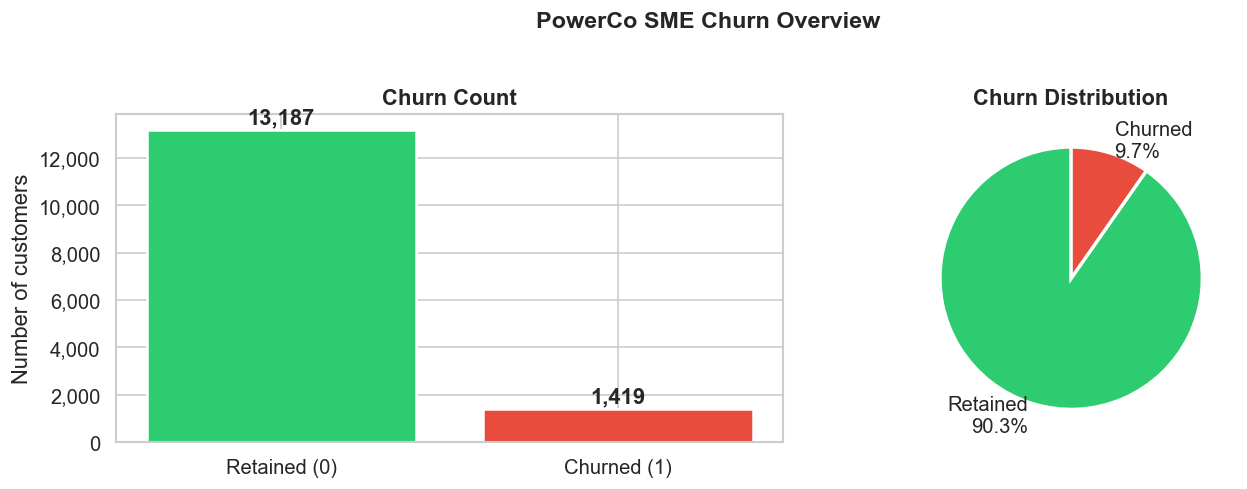

Churn rate: 9.72%  |  Retained: 90.28%


In [11]:
churn_counts = client_df['churn'].value_counts()
churn_pct    = client_df['churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
bars = axes[0].bar(['Retained (0)', 'Churned (1)'],
                    churn_counts.values,
                    color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Churn Count', fontweight='bold')
axes[0].set_ylabel('Number of customers')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Percentage pie
axes[1].pie(churn_pct.values, labels=[f'Retained\n{churn_pct[0]:.1f}%', f'Churned\n{churn_pct[1]:.1f}%'],
            colors=['#2ecc71', '#e74c3c'], autopct='', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Distribution', fontweight='bold')

plt.suptitle('PowerCo SME Churn Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/01_churn_overview.png', bbox_inches='tight')
plt.show()
print(f'Churn rate: {churn_pct[1]:.2f}%  |  Retained: {churn_pct[0]:.2f}%')

> **Finding:** The dataset is **imbalanced** — only 9.7% churn rate. This must be accounted for in modelling (class weighting or resampling). A naive model predicting "always retain" would achieve 90.3% accuracy but zero recall for churners.

## 7. Categorical Feature Analysis

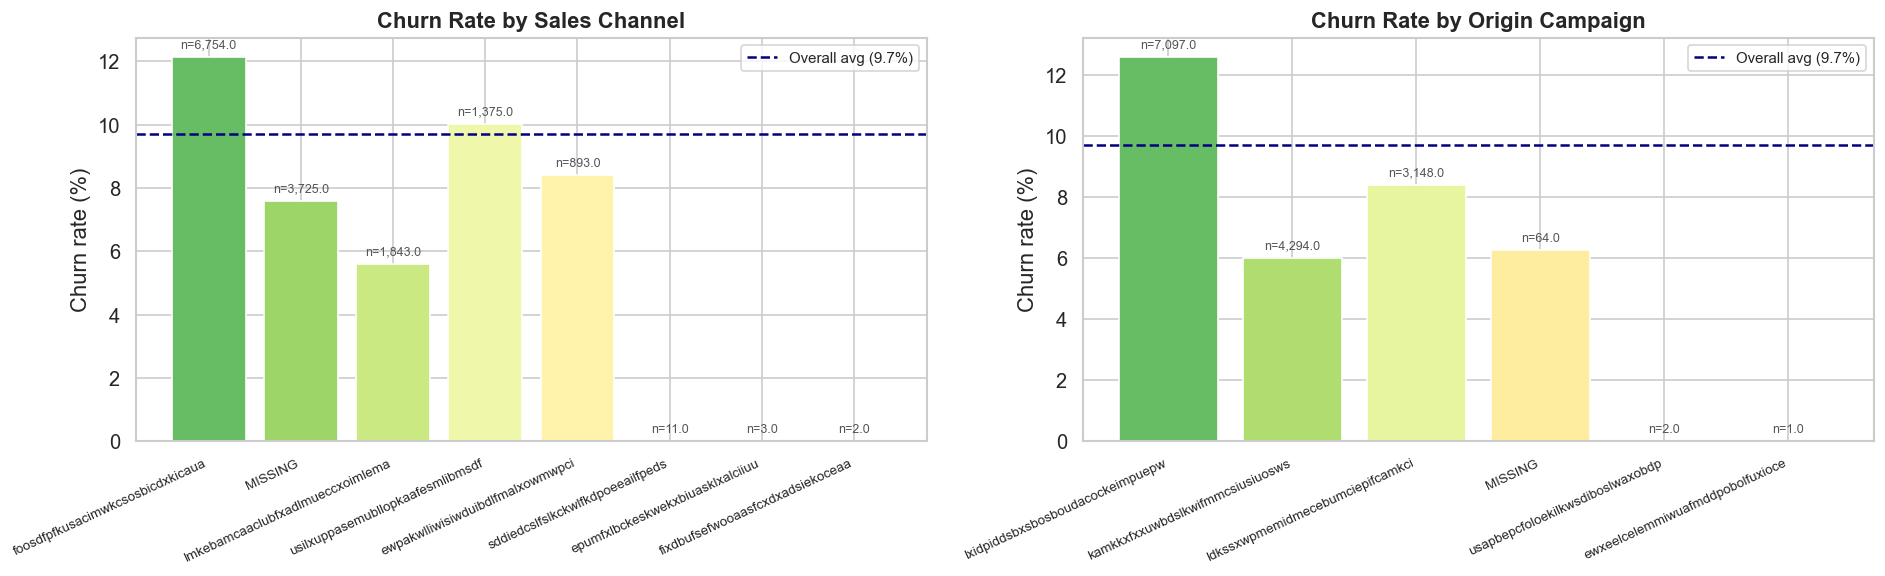

In [12]:
def plot_churn_by_category(df, col, title, ax, top_n=10):
    """Plot churn rate and volume for a categorical column."""
    grp = (df.groupby(col)['churn']
             .agg(['mean', 'count'])
             .rename(columns={'mean': 'churn_rate', 'count': 'n'})
             .sort_values('n', ascending=False)
             .head(top_n))
    grp['churn_rate'] = grp['churn_rate'] * 100
    
    color_map = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(grp)))
    bars = ax.bar(grp.index, grp['churn_rate'], color=color_map, edgecolor='white')
    ax.axhline(client_df['churn'].mean() * 100, color='navy', linestyle='--',
                linewidth=1.5, label=f'Overall avg ({client_df["churn"].mean()*100:.1f}%)')
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'n={row["n"]:,}', ha='center', va='bottom', fontsize=7.5, color='#555')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Churn rate (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right', fontsize=8)
    ax.legend(fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_churn_by_category(client_df, 'channel_sales', 'Churn Rate by Sales Channel', axes[0])
plot_churn_by_category(client_df, 'origin_up', 'Churn Rate by Origin Campaign', axes[1])
plt.tight_layout()
plt.savefig('../reports/figures/02_churn_by_category.png', bbox_inches='tight')
plt.show()

## 8. Numerical Feature Distributions

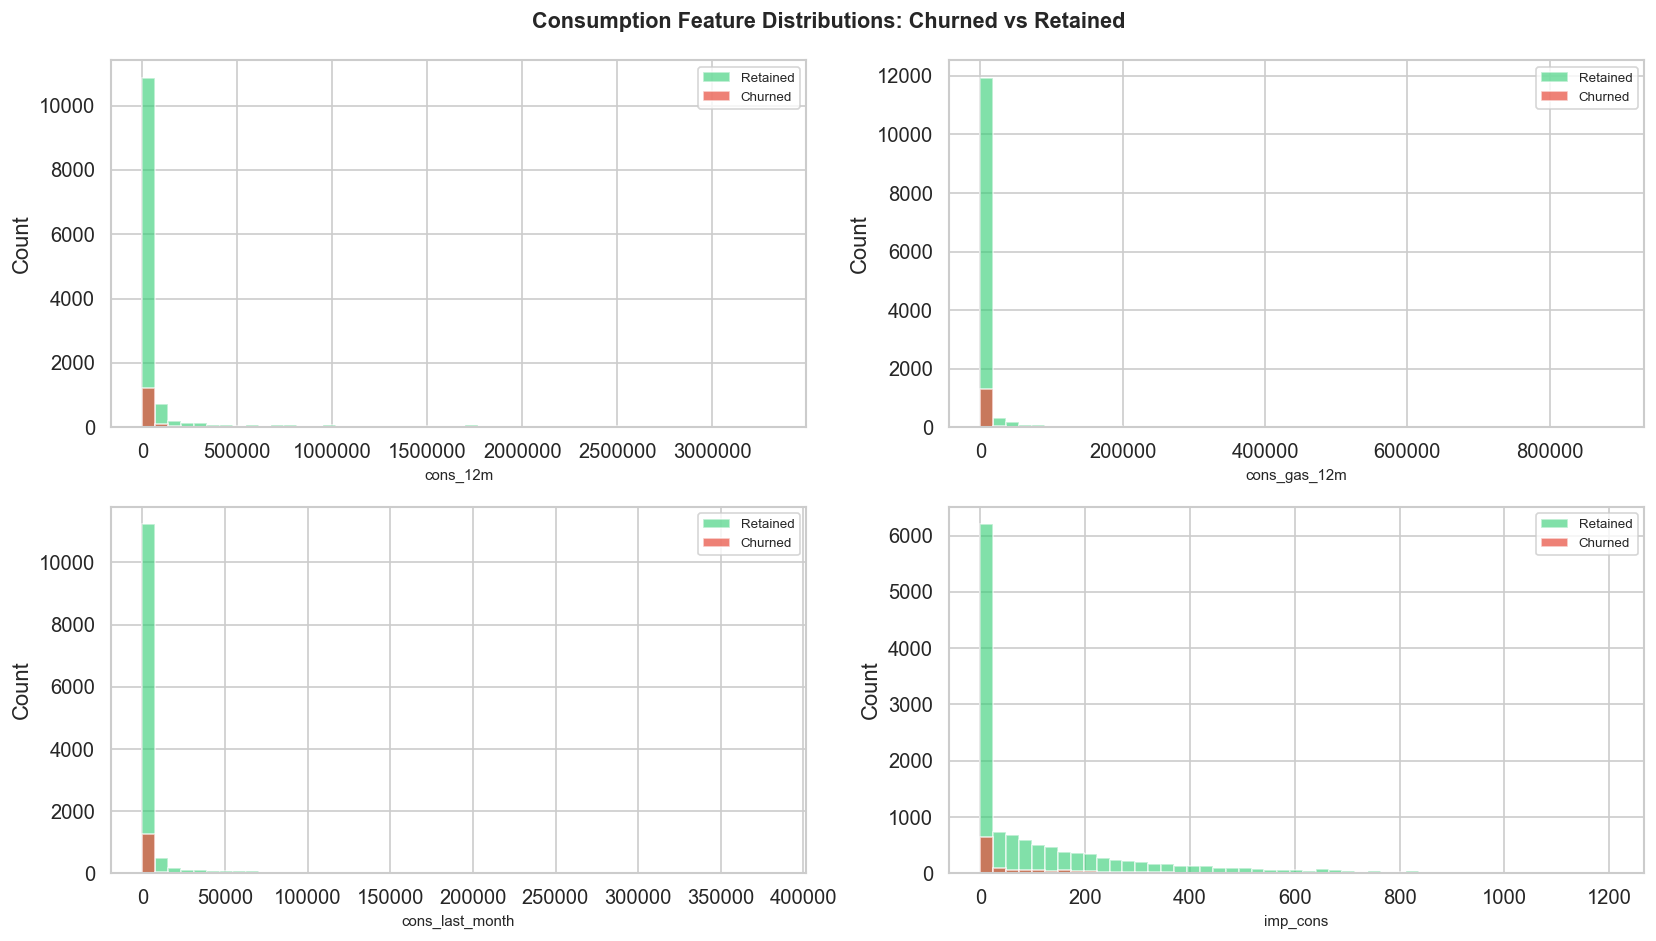

In [13]:
def plot_distribution(df, col, ax, log_scale=False):
    """Stacked histogram of retained vs churned."""
    retained = df[df['churn'] == 0][col].dropna()
    churned  = df[df['churn'] == 1][col].dropna()
    bins = np.linspace(
        min(retained.min(), churned.min()),
        np.percentile(df[col].dropna(), 99), 50
    )
    ax.hist(retained, bins=bins, alpha=0.6, color='#2ecc71', label='Retained')
    ax.hist(churned,  bins=bins, alpha=0.7, color='#e74c3c', label='Churned')
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.ticklabel_format(style='plain', axis='x')
    if log_scale:
        ax.set_yscale('log')

consumption_cols = ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), consumption_cols):
    plot_distribution(client_df, col, ax)
fig.suptitle('Consumption Feature Distributions: Churned vs Retained', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/03_consumption_distributions.png', bbox_inches='tight')
plt.show()

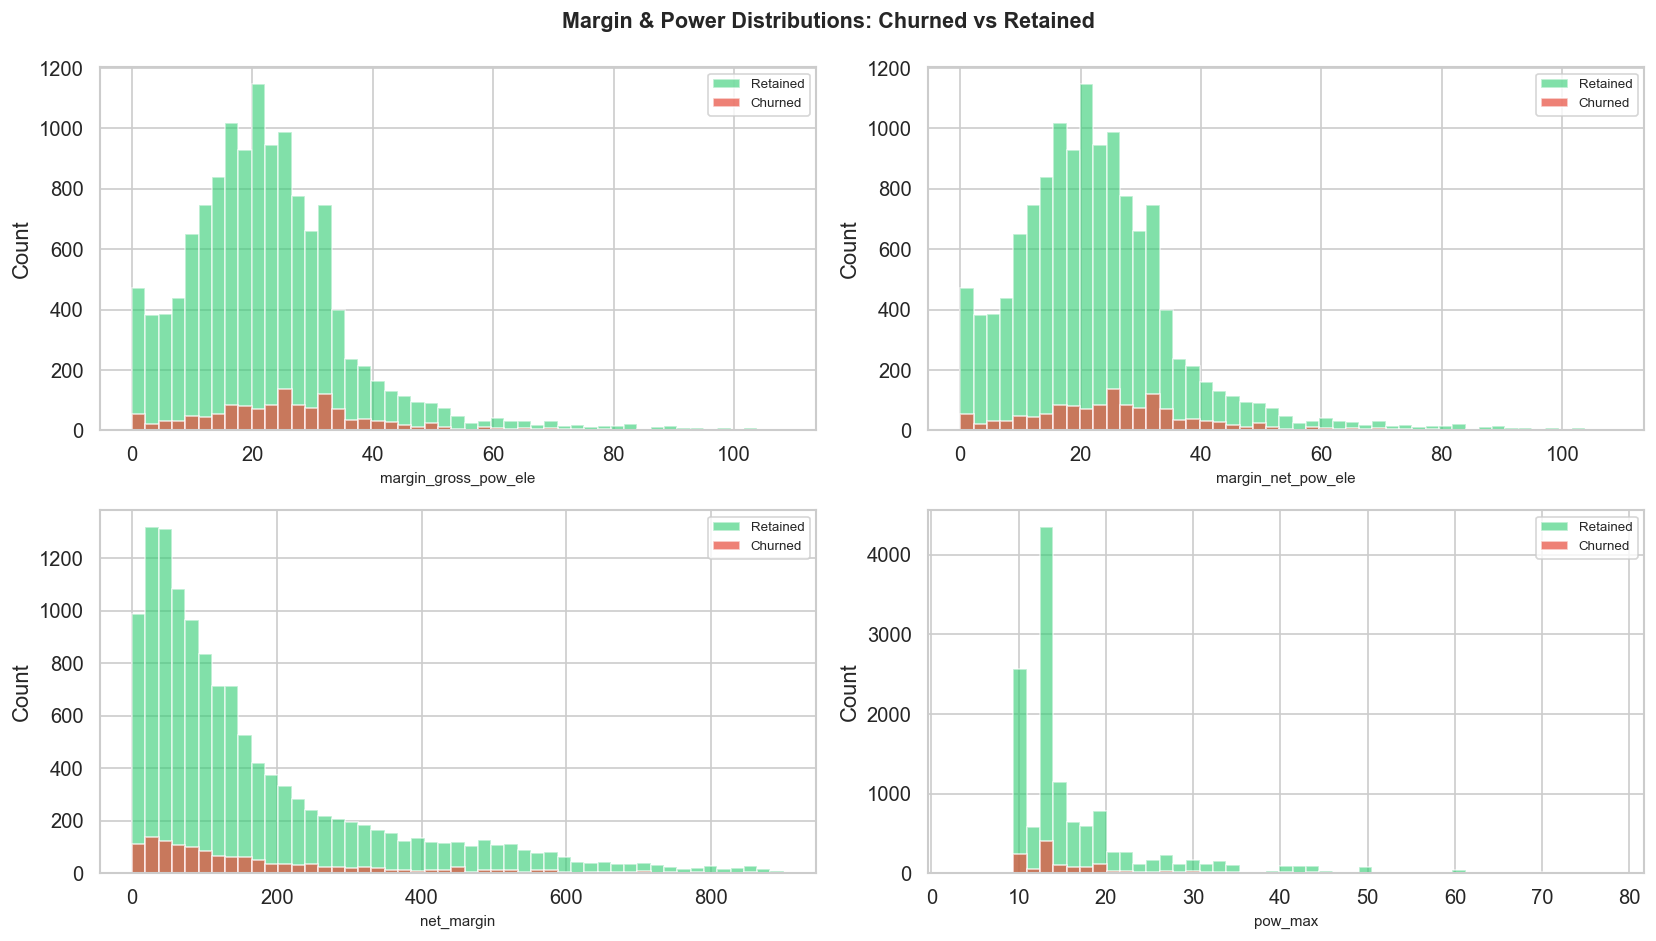

In [14]:
margin_cols = ['margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin', 'pow_max']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.flatten(), margin_cols):
    plot_distribution(client_df, col, ax)
fig.suptitle('Margin & Power Distributions: Churned vs Retained', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/04_margin_distributions.png', bbox_inches='tight')
plt.show()

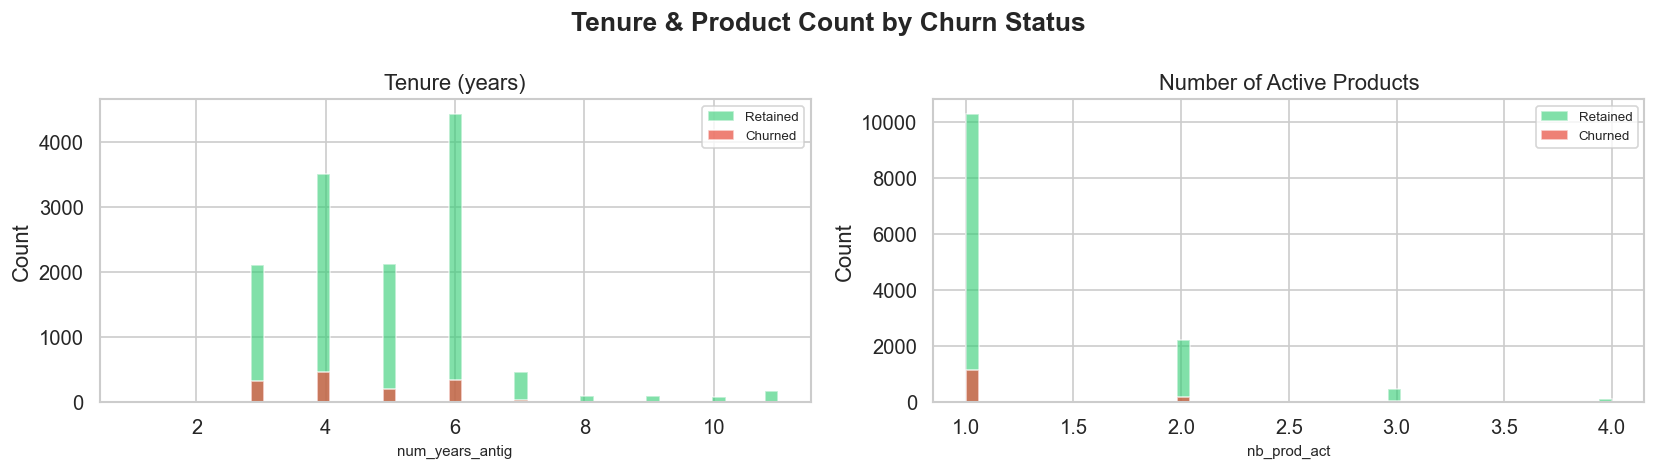

In [15]:
# Tenure and product count
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_distribution(client_df, 'num_years_antig', axes[0])
axes[0].set_title('Tenure (years)')
plot_distribution(client_df, 'nb_prod_act', axes[1])
axes[1].set_title('Number of Active Products')
plt.suptitle('Tenure & Product Count by Churn Status', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/05_tenure_products.png', bbox_inches='tight')
plt.show()

## 9. Price Data Analysis

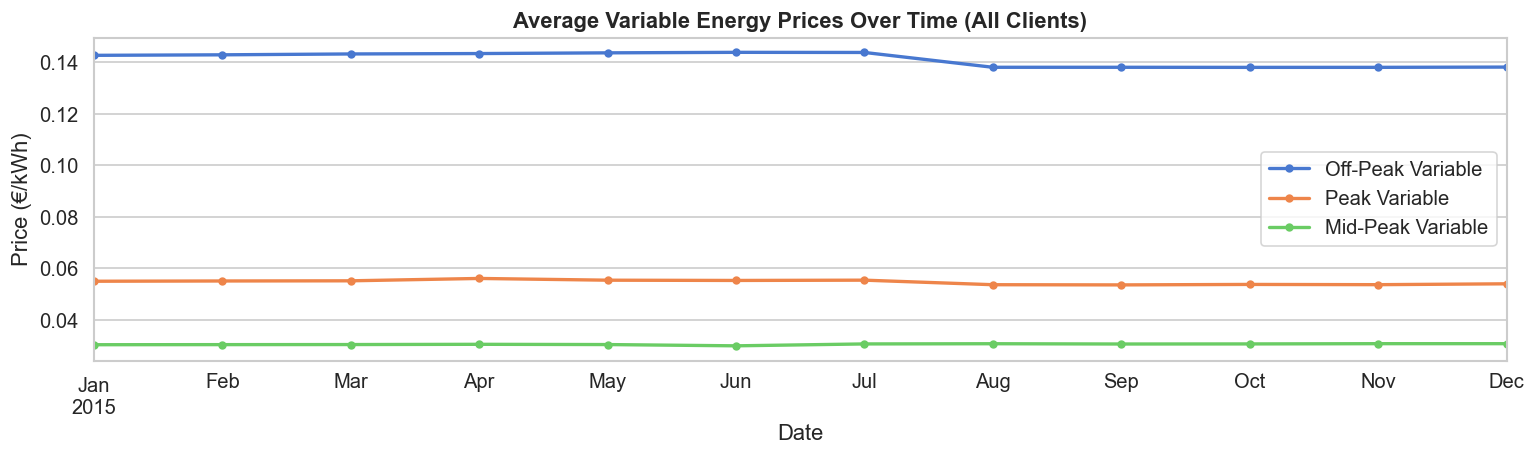

In [16]:
# Parse dates
price_df['price_date'] = pd.to_datetime(price_df['price_date'])

# Average prices over time across all customers
price_trend = price_df.groupby('price_date')[['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var']].mean()

fig, ax = plt.subplots(figsize=(13, 4))
price_trend.plot(ax=ax, marker='o', markersize=4, linewidth=2)
ax.set_title('Average Variable Energy Prices Over Time (All Clients)', fontweight='bold')
ax.set_ylabel('Price (€/kWh)')
ax.set_xlabel('Date')
ax.legend(['Off-Peak Variable', 'Peak Variable', 'Mid-Peak Variable'])
plt.tight_layout()
plt.savefig('../reports/figures/06_price_trends.png', bbox_inches='tight')
plt.show()

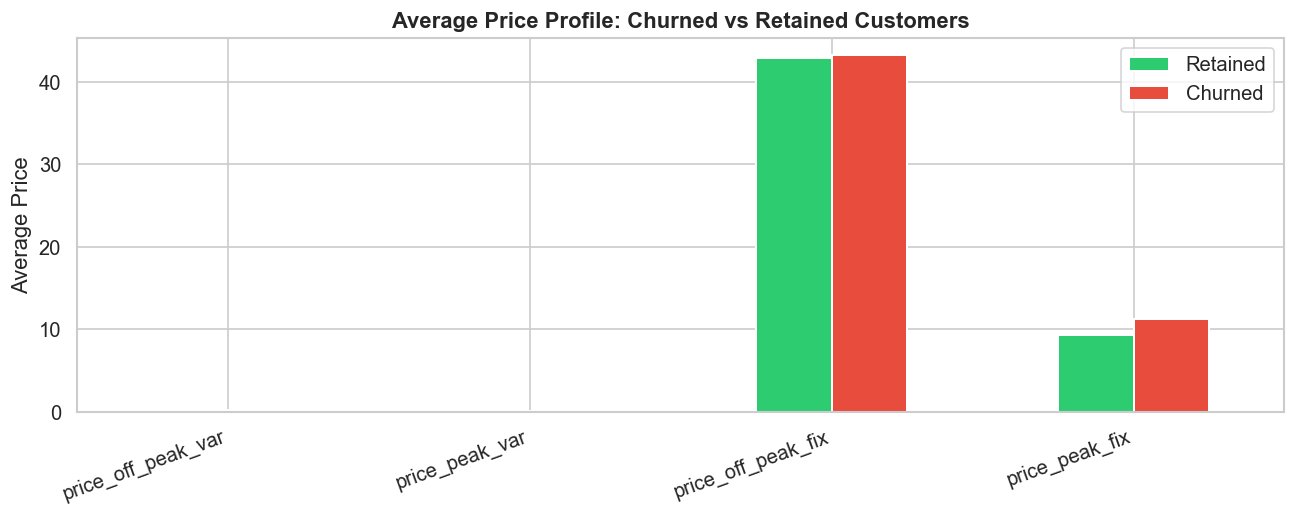

                     Retained    Churned
price_off_peak_var   0.142377   0.141898
price_peak_var       0.051575   0.056554
price_off_peak_fix  42.903794  43.163536
price_peak_fix       9.272559  11.192617


In [17]:
# Merge churn label into price data for comparison
churn_labels = client_df[['id', 'churn']]
price_with_churn = price_df.merge(churn_labels, on='id', how='left')

# Average price profile: churned vs retained
price_profile = price_with_churn.groupby('churn')[[
    'price_off_peak_var', 'price_peak_var', 'price_off_peak_fix', 'price_peak_fix'
]].mean().T
price_profile.columns = ['Retained', 'Churned']

ax = price_profile.plot(kind='bar', figsize=(11, 4.5), color=['#2ecc71', '#e74c3c'],
                         edgecolor='white', linewidth=1.2)
ax.set_title('Average Price Profile: Churned vs Retained Customers', fontweight='bold')
ax.set_ylabel('Average Price')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/07_price_churn_comparison.png', bbox_inches='tight')
plt.show()
print(price_profile)

## 10. Correlation Analysis

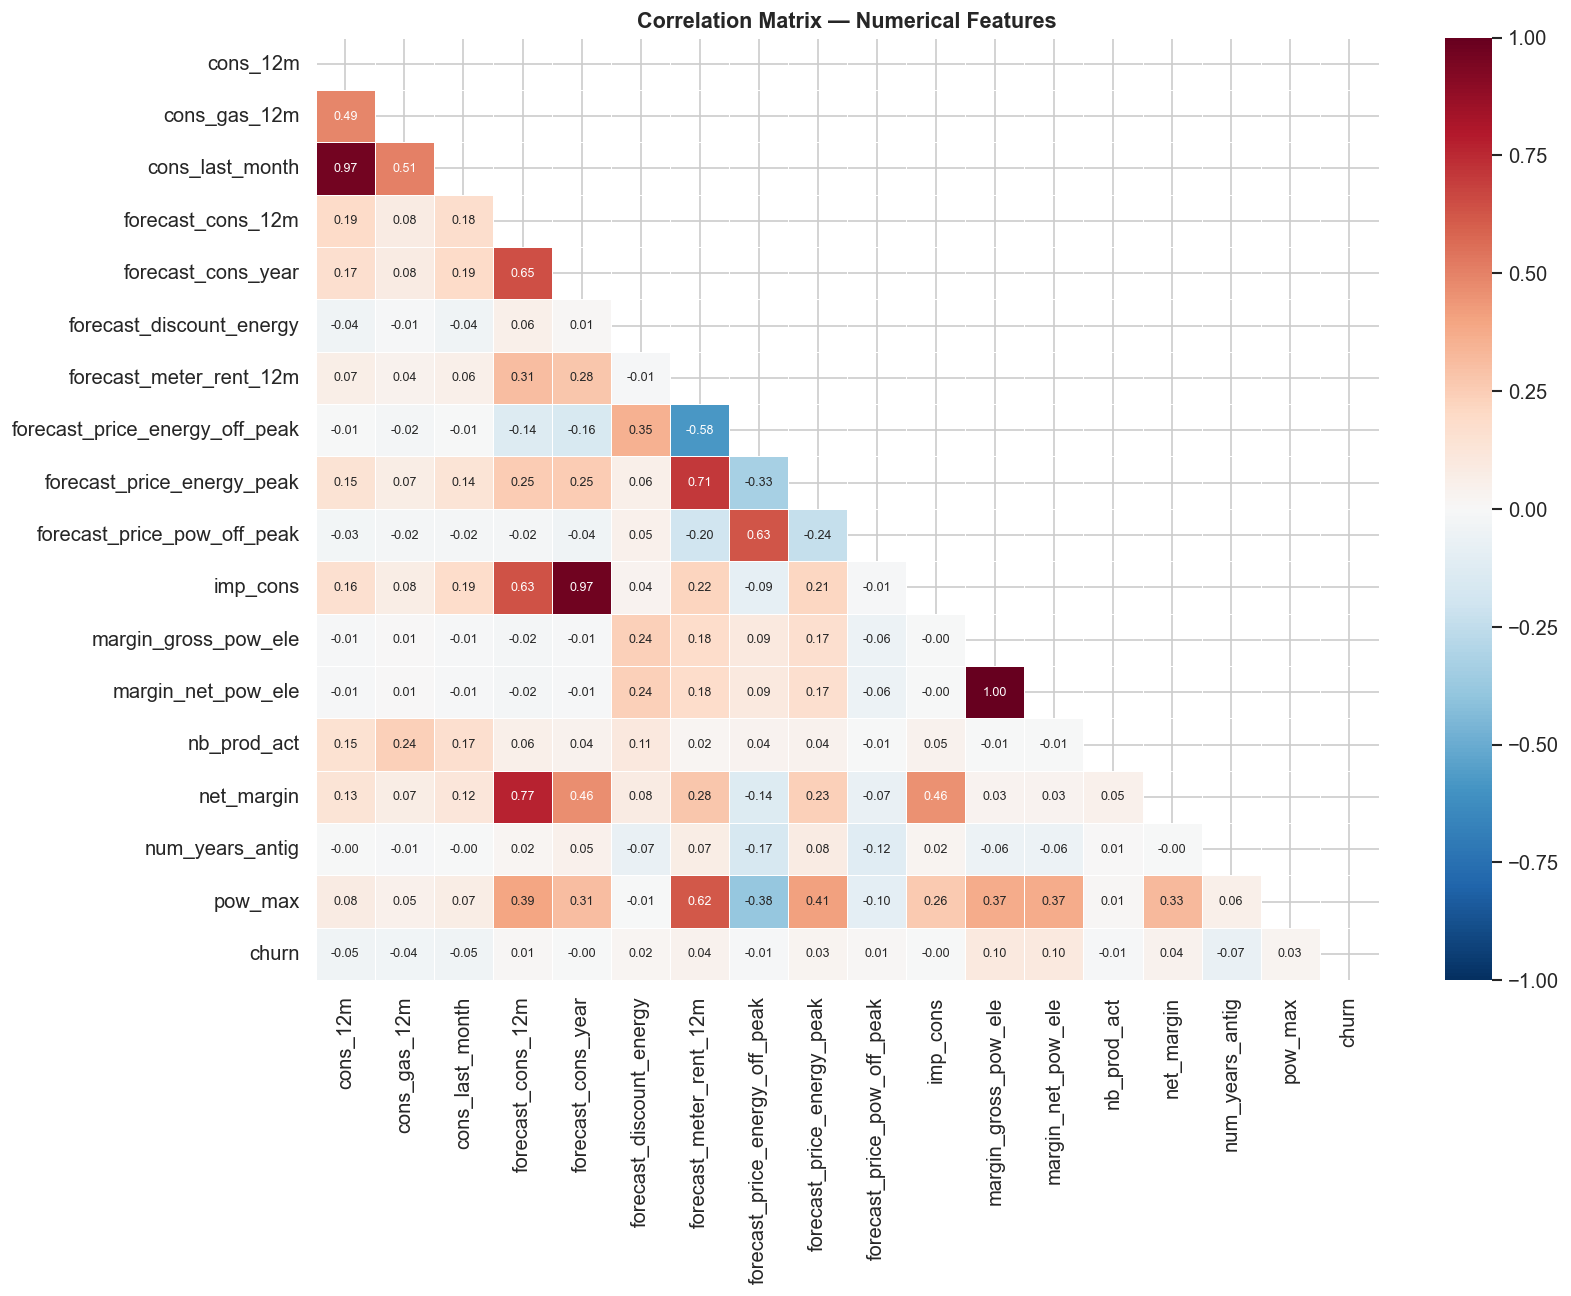

In [18]:
numeric_cols = client_df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = client_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 7.5})
ax.set_title('Correlation Matrix — Numerical Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/08_correlation_matrix.png', bbox_inches='tight')
plt.show()

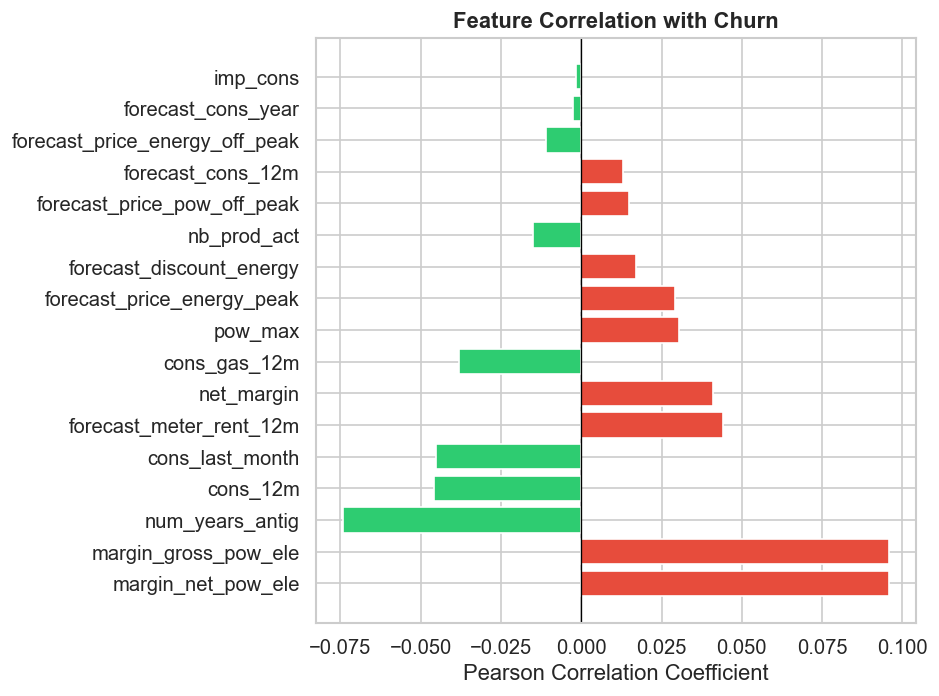

margin_net_pow_ele                0.095772
margin_gross_pow_ele              0.095725
num_years_antig                  -0.074140
cons_12m                         -0.045968
cons_last_month                  -0.045284
forecast_meter_rent_12m           0.044245
net_margin                        0.041135
cons_gas_12m                     -0.037957
pow_max                           0.030362
forecast_price_energy_peak        0.029315
forecast_discount_energy          0.017026
nb_prod_act                      -0.014930
forecast_price_pow_off_peak       0.014778
forecast_cons_12m                 0.012949
forecast_price_energy_off_peak   -0.010837
forecast_cons_year               -0.002558
imp_cons                         -0.001583
Name: churn, dtype: float64


In [19]:
# Correlation with churn — sorted
churn_corr = corr_matrix['churn'].drop('churn').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in churn_corr.values]
ax.barh(churn_corr.index, churn_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with Churn', fontweight='bold')
ax.set_xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('../reports/figures/09_churn_correlations.png', bbox_inches='tight')
plt.show()
print(churn_corr)

## 11. Has Gas Analysis

         Churn Rate  Count
has_gas                   
No Gas        10.05  11955
Has Gas        8.19   2651


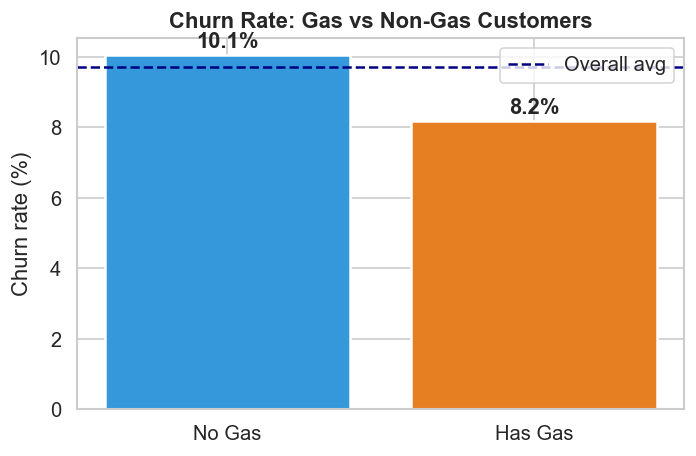

In [20]:
gas_churn = client_df.groupby('has_gas')['churn'].agg(['mean', 'count'])
gas_churn.columns = ['Churn Rate', 'Count']
gas_churn['Churn Rate'] = (gas_churn['Churn Rate'] * 100).round(2)
gas_churn.index = gas_churn.index.map({'t': 'Has Gas', 'f': 'No Gas'})
print(gas_churn)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(gas_churn.index, gas_churn['Churn Rate'],
               color=['#3498db', '#e67e22'], edgecolor='white', linewidth=1.5)
ax.axhline(client_df['churn'].mean()*100, color='navy', linestyle='--', label='Overall avg')
for bar, val in zip(bars, gas_churn['Churn Rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.set_title('Churn Rate: Gas vs Non-Gas Customers', fontweight='bold')
ax.set_ylabel('Churn rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/10_gas_churn.png', bbox_inches='tight')
plt.show()

## 12. Data Cleaning

In [21]:
print('=== BEFORE CLEANING ===')
print(f'client_df shape : {client_df.shape}')
print(f'has_gas dtype   : {client_df["has_gas"].dtype}')
print(f'date_activ dtype: {client_df["date_activ"].dtype}')
print(f'MISSING channel : {(client_df["channel_sales"]=="MISSING").sum()}')
print(f'nb_prod_act > 10: {(client_df["nb_prod_act"] > 10).sum()} rows')

=== BEFORE CLEANING ===
client_df shape : (14606, 26)
has_gas dtype   : object
date_activ dtype: object
MISSING channel : 3725
nb_prod_act > 10: 1 rows


In [22]:
client_clean = client_df.copy()
price_clean  = price_df.copy()

# --- 1. Convert has_gas to boolean integer ---
client_clean['has_gas'] = client_clean['has_gas'].map({'t': 1, 'f': 0})

# --- 2. Parse date columns ---
date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']
for col in date_cols:
    client_clean[col] = pd.to_datetime(client_clean[col], errors='coerce')
price_clean['price_date'] = pd.to_datetime(price_clean['price_date'], errors='coerce')

# --- 3. Replace 'MISSING' sentinel with NaN ---
client_clean['channel_sales'] = client_clean['channel_sales'].replace('MISSING', np.nan)

# --- 4. Cap nb_prod_act outlier (32 is almost certainly a data error; cap at 6) ---
cap_99 = client_clean['nb_prod_act'].quantile(0.99)
print(f'nb_prod_act 99th percentile: {cap_99}')
client_clean['nb_prod_act'] = client_clean['nb_prod_act'].clip(upper=cap_99)

# --- 5. Verify ---
print('\n=== AFTER CLEANING ===')
print(f'has_gas dtype        : {client_clean["has_gas"].dtype}')
print(f'date_activ dtype     : {client_clean["date_activ"].dtype}')
print(f'Null channel_sales   : {client_clean["channel_sales"].isnull().sum()}')
print(f'nb_prod_act max      : {client_clean["nb_prod_act"].max()}')
print(f'Null dates (activ)   : {client_clean["date_activ"].isnull().sum()}')

nb_prod_act 99th percentile: 4.0

=== AFTER CLEANING ===
has_gas dtype        : int64
date_activ dtype     : datetime64[ns]
Null channel_sales   : 3725
nb_prod_act max      : 4
Null dates (activ)   : 0


In [23]:
# Missing values after cleaning
_ = missing_summary(client_clean, 'client_clean')


--- client_clean: missing values ---
               missing_count  missing_pct
channel_sales           3725         25.5


## 13. Outlier Investigation

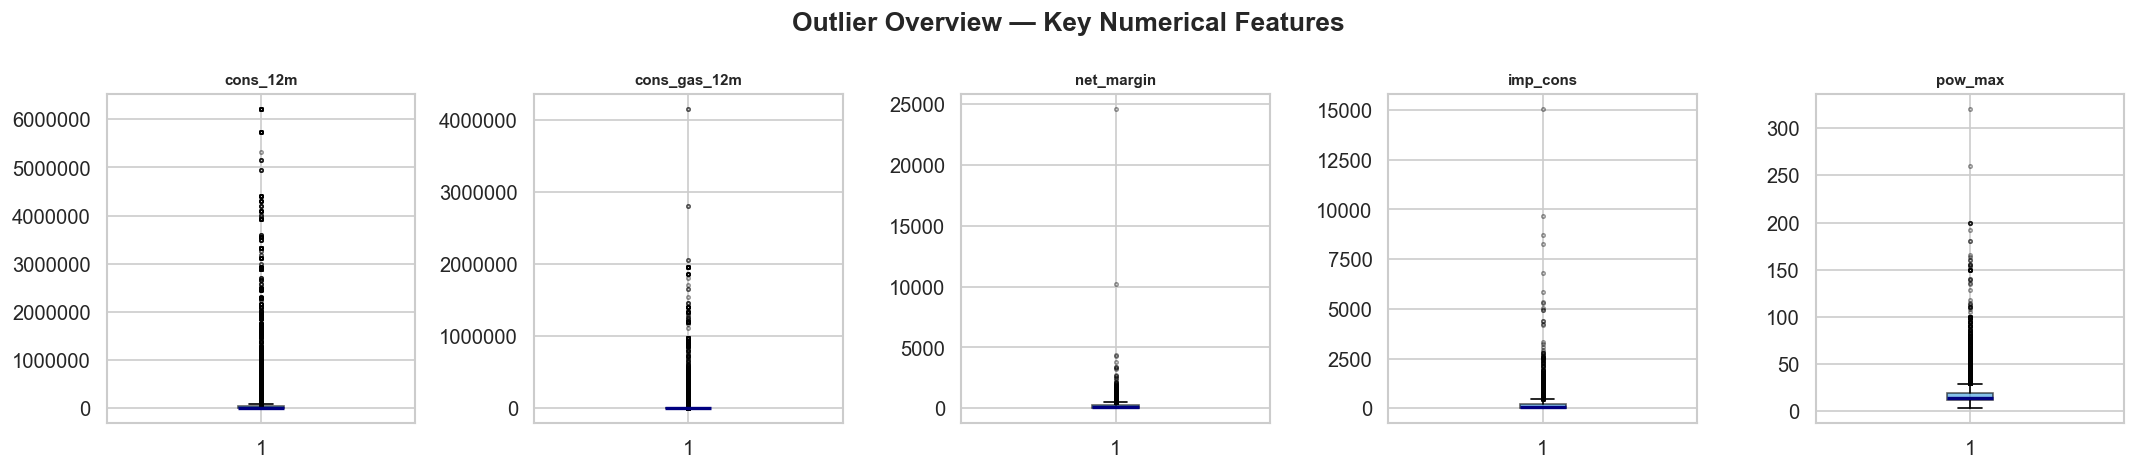

In [24]:
outlier_cols = ['cons_12m', 'cons_gas_12m', 'net_margin', 'imp_cons', 'pow_max']

fig, axes = plt.subplots(1, len(outlier_cols), figsize=(18, 4))
for ax, col in zip(axes, outlier_cols):
    ax.boxplot(client_clean[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.6),
               medianprops=dict(color='navy', linewidth=2),
               flierprops=dict(marker='o', markersize=2, alpha=0.4, color='#e74c3c'))
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.ticklabel_format(style='plain', axis='y')

plt.suptitle('Outlier Overview — Key Numerical Features', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/11_outliers.png', bbox_inches='tight')
plt.show()

In [25]:
# IQR-based outlier counts (not removing — tree models are robust to outliers)
def iqr_outlier_count(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)).sum()

outlier_summary = pd.DataFrame({
    'outlier_count': {col: iqr_outlier_count(client_clean[col]) for col in outlier_cols},
})
outlier_summary['outlier_pct'] = (outlier_summary['outlier_count'] / len(client_clean) * 100).round(2)
print(outlier_summary.sort_values('outlier_count', ascending=False))
print('\nNote: Outliers are NOT removed — Random Forest is robust to extreme values.')

              outlier_count  outlier_pct
cons_gas_12m           2612        17.88
cons_12m               2084        14.27
pow_max                1535        10.51
imp_cons               1215         8.32
net_margin             1022         7.00

Note: Outliers are NOT removed — Random Forest is robust to extreme values.


## 14. Contract Duration Analysis

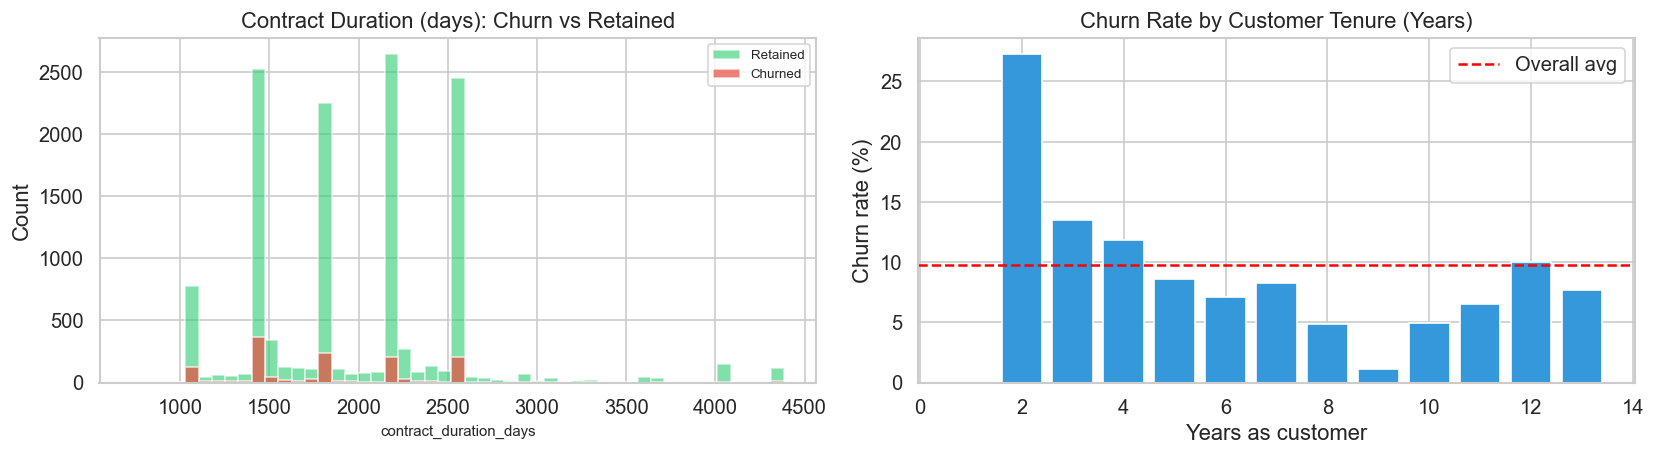

In [26]:
# Contract duration in days
client_clean['contract_duration_days'] = (client_clean['date_end'] - client_clean['date_activ']).dt.days
client_clean['months_to_renewal'] = (client_clean['date_renewal'] - client_clean['date_end']).dt.days / 30.44

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_distribution(client_clean, 'contract_duration_days', axes[0])
axes[0].set_title('Contract Duration (days): Churn vs Retained')

# Tenure vs churn rate
tenure_churn = client_clean.groupby('num_years_antig')['churn'].mean() * 100
axes[1].bar(tenure_churn.index, tenure_churn.values, color='#3498db', edgecolor='white')
axes[1].axhline(client_clean['churn'].mean()*100, color='red', linestyle='--', label='Overall avg')
axes[1].set_title('Churn Rate by Customer Tenure (Years)')
axes[1].set_xlabel('Years as customer')
axes[1].set_ylabel('Churn rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/12_contract_tenure.png', bbox_inches='tight')
plt.show()

## 15. EDA Summary & Key Findings

### Data Quality Issues Fixed
| Issue | Column | Fix Applied |
|---|---|---|
| String booleans | `has_gas` (t/f) | Mapped to 1/0 integer |
| Object date strings | `date_activ`, `date_end`, `date_modif_prod`, `date_renewal`, `price_date` | Parsed to `datetime64` |
| Sentinel missing value | `channel_sales` ('MISSING') | Replaced with `NaN` |
| Extreme outlier | `nb_prod_act` (max=32) | Capped at 99th percentile |

### Key EDA Findings

1. **Churn rate is 9.7%** — the dataset is imbalanced and requires class-weight adjustment in modelling
2. **Price differences between churned and retained are small** — price alone is unlikely to fully explain churn (consistent with BCG's guidance that price sensitivity partially drives churn)
3. **`num_years_antig` (tenure)** shows that newer customers churn at higher rates — loyalty is a strong signal
4. **`has_gas` customers** churn at a lower rate — multi-product relationships increase stickiness
5. **Consumption features** are highly skewed with extreme outliers — log transforms will be valuable for linear models, but Random Forest handles this natively
6. **`channel_sales`** has meaningful churn rate variation — acquisition channel matters for retention
7. **Price data is stable** for most clients month-over-month — the key signal will be *relative* prices, not absolute levels

## 16. Save Cleaned Data

In [27]:
# Drop the temporary columns added during EDA before saving
client_clean_save = client_clean.drop(columns=['contract_duration_days', 'months_to_renewal'], errors='ignore')

client_clean_save.to_csv(DATA_PROC / 'client_data_clean.csv', index=False)
price_clean.to_csv(DATA_PROC / 'price_data_clean.csv', index=False)

print('Saved to data/processed/')
print(f'  client_data_clean.csv : {client_clean_save.shape}')
print(f'  price_data_clean.csv  : {price_clean.shape}')

Saved to data/processed/
  client_data_clean.csv : (14606, 26)
  price_data_clean.csv  : (193002, 8)


---
> **Next:** Proceed to [03_feature_engineering_modelling.ipynb](03_feature_engineering_modelling.ipynb) to engineer features and build the churn prediction model.